In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Load the Excel file
df = pd.read_excel('diving_beetle_swimming_forward_trajectory.ods')
# df = pd.read_excel('diving_beetle_swimming_turning_trajectory.ods')

# Display the first few rows
print(df.head())

   Frames  Times/ms  angle τ/°  angle α/°  angle β/°  angle γ/°  angle δ/°  \
0       1         0   93.95306  144.37750  178.61206  175.71780  173.66432   
1       2         1   94.71214  144.84556  178.74648  176.18096  174.20333   
2       3         2   95.52483  145.31361  178.88091  176.64412  174.74235   
3       4         3   96.38058  145.78167  179.01534  177.10728  175.28136   
4       5         4   97.27003  146.24973  179.14977  177.57043  175.82037   

   angle θ/°  angle φ/°  V/(cm s-1)  
0  172.75744  171.99257     6.60253  
1  173.31601  172.51234     6.73747  
2  173.87458  173.03212     6.87242  
3  174.43315  173.55189     7.00737  
4  174.99172  174.07166     7.14232  


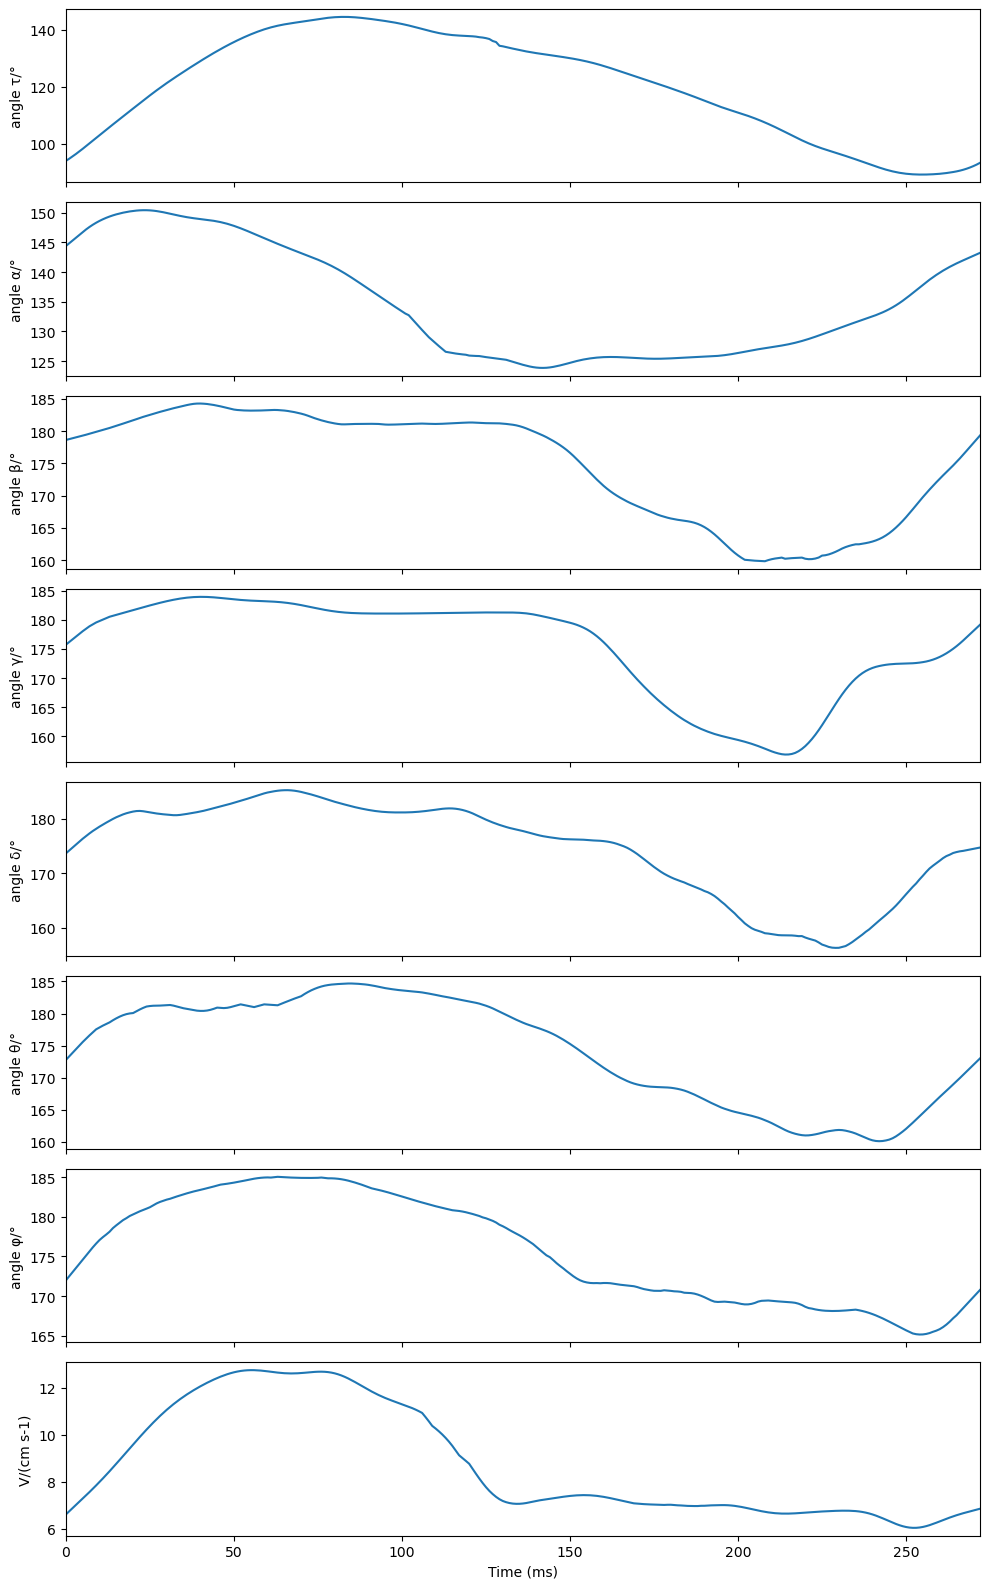

In [4]:

# Time axis
time = df["Times/ms"]

# Create figure
time = pd.to_numeric(df["Times/ms"], errors="coerce").to_numpy()

columns = [
    "angle τ/°", "angle α/°", "angle β/°",
    "angle γ/°", "angle δ/°", "angle θ/°",
    "angle φ/°", "V/(cm s-1)"
]

fig, axes = plt.subplots(len(columns), 1, figsize=(10, 16), sharex=True)

for i, col in enumerate(columns):
    y = pd.to_numeric(df[col], errors="coerce").to_numpy()
    axes[i].plot(time, y)
    axes[i].set_ylabel(col)
    axes[i].grid(False)
    axes[i].set_xlim(time[0], time[-1])

axes[-1].set_xlabel("Time (ms)")

plt.tight_layout()

plt.show()

# Kinematic model

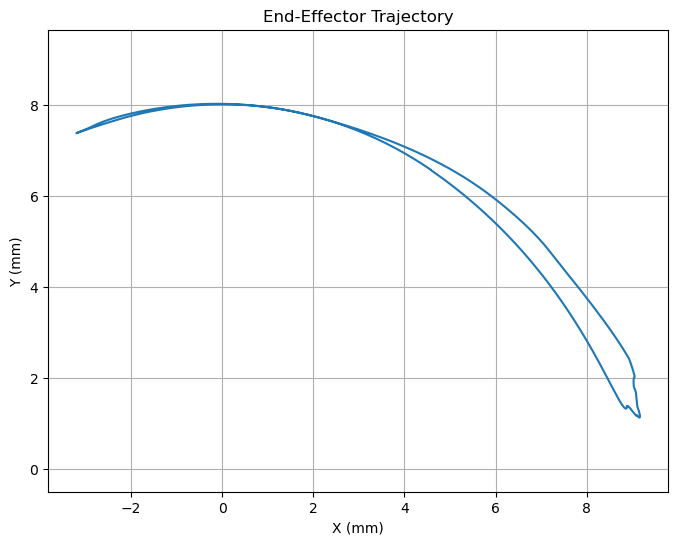

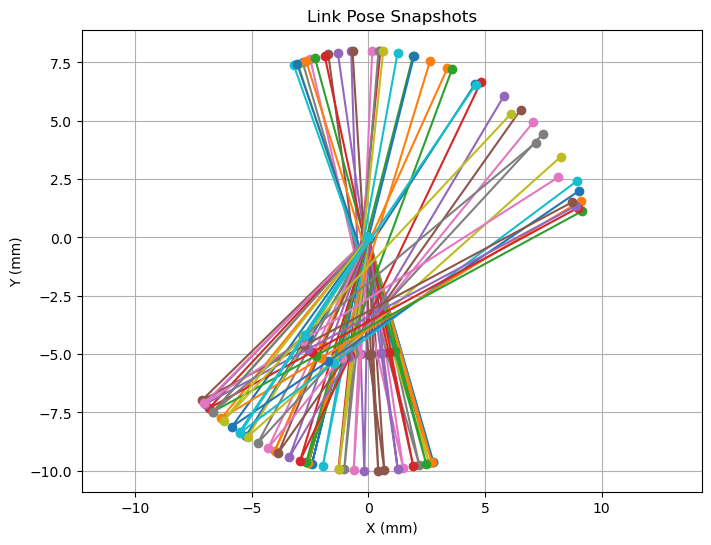

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load data
# ----------------------------
df = pd.read_excel('diving_beetle_swimming_forward_trajectory.ods')

# Convert degrees → radians
deg2rad = np.pi / 180.0

tau   = df["angle τ/°"].to_numpy() * deg2rad
alpha = df["angle α/°"].to_numpy() * deg2rad
beta  = df["angle β/°"].to_numpy() * deg2rad
psi4  = df["angle γ/°"].to_numpy() * deg2rad   # adjust if ψ4 is different column

# ----------------------------
# DH parameters (mm)
# ----------------------------
a1 = 10
a2 = 5

# ----------------------------
# DH transform
# ----------------------------
def dh(a, alpha, d, theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),               np.cos(alpha),               d],
        [0,              0,                           0,                           1]
    ])

# ----------------------------
# Compute trajectory
# ----------------------------
trajectory = []
all_links = []

for i in range(len(df)):
    
    T1 = dh(0, 0, 0, tau[i])
    T2 = dh(a1, 0, 0, alpha[i])
    T3 = dh(a2, 0, 0, beta[i])
    T4 = dh(13, -np.pi/2, 0, 0)
    
    T01 = T1
    T02 = T01 @ T2
    T03 = T02 @ T3
    T04 = T03 @ T4
    
    p0 = np.array([0,0,0])
    p1 = T01[:3,3]
    p2 = T02[:3,3]
    p3 = T03[:3,3]
    p4 = T04[:3,3]
    
    trajectory.append(p4)
    all_links.append([p0, p1, p2, p3, p4])

trajectory = np.array(trajectory)

# ----------------------------
# Plot trajectory
# ----------------------------
plt.figure(figsize=(8,6))
plt.plot(trajectory[:,0], trajectory[:,1])
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("End-Effector Trajectory")
plt.axis("equal")
plt.grid(True)
plt.show()

# ----------------------------
# Plot link pose snapshots
# ----------------------------
plt.figure(figsize=(8,6))

for k in np.linspace(0, len(all_links)-1, 40, dtype=int):
    links = np.array(all_links[k])
    plt.plot(links[:,0], links[:,1], '-o')

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Link Pose Snapshots")
plt.axis("equal")
plt.grid(True)
plt.show()

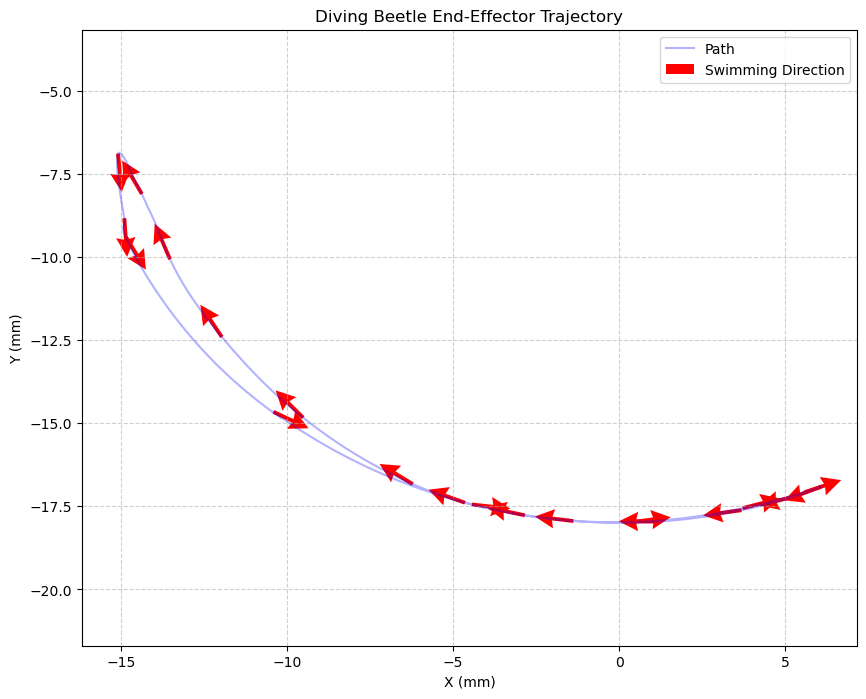

In [6]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# 1. Load data (assuming the file is in your local directory)
df = pd.read_excel('diving_beetle_swimming_forward_trajectory.ods')

# Convert degrees → radians
deg2rad = np.pi / 180.0
tau   = df["angle τ/°"].to_numpy() * deg2rad
alpha = df["angle α/°"].to_numpy() * deg2rad
beta  = df["angle β/°"].to_numpy() * deg2rad
psi4  = df["angle γ/°"].to_numpy() * deg2rad

# 2. DH Parameters (mm) based on the ESM Document
a1, a2, a3 = 10, 5, 13  # Lengths of Link I, II, and III 

def dh_matrix(a, alpha, d, theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),               np.cos(alpha),               d],
        [0,              0,                           0,                           1]
    ])

# 3. Compute Kinematics
all_joint_positions = [] # To store [p0, p1, p2, p3, p4] for snapshots
tip_trajectory = []

for i in range(len(df)):
    # Chain of transformations according to the document [cite: 74]
    T1 = dh_matrix(0, 0, 0, tau[i])
    T2 = dh_matrix(a1, 0, 0, alpha[i])
    T3 = dh_matrix(a2, 0, 0, beta[i])
    T4 = dh_matrix(a3, -np.pi/2, 0, psi4[i]) # a3 is the distal link length
    
    T01 = T1
    T02 = T01 @ T2
    T03 = T02 @ T3
    T04 = T03 @ T4
    
    p0 = np.array([0,0,0])
    p1 = T01[:3,3]
    p2 = T02[:3,3]
    p3 = T03[:3,3]
    p4 = T04[:3,3]
    
    all_joint_positions.append([p0, p1, p2, p3, p4])
    tip_trajectory.append(p4)

tip_trajectory = np.array(tip_trajectory)
trajectory = np.array(tip_trajectory)

plt.figure(figsize=(10, 8))

# 1. Plot the continuous trajectory line (Full path)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='blue', alpha=0.3, label='Path')

# 2. Corrected Directional Arrows
# We use a step to avoid a crowded plot
step = max(1, len(trajectory) // 20)

# Slicing the trajectory for arrow bases
# To avoid the ValueError, the number of positions must match the number of diffs
x_pos = trajectory[::step, 0]
y_pos = trajectory[::step, 1]

# Calculate displacement vectors between the sampled points
u = np.diff(x_pos)
v = np.diff(y_pos)

# Now slice the positions to match the length of u and v (Size N-1)
x_arrow = x_pos[:-1]
y_arrow = y_pos[:-1]

# Normalize for uniform arrow size to show direction clearly
norm = np.sqrt(u**2 + v**2)
u_norm = u / norm
v_norm = v / norm

# Plot the arrows
plt.quiver(x_arrow, y_arrow, u_norm, v_norm, color='red', 
           scale=20, width=0.005, headwidth=5, label='Swimming Direction')

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Diving Beetle End-Effector Trajectory")
plt.axis("equal")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

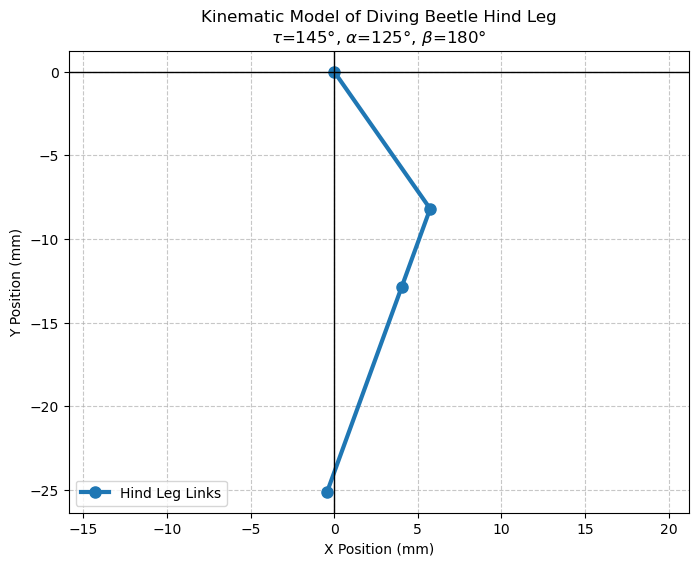

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_diving_beetle_leg(tau_deg, alpha_deg, beta_deg):
    # Convert degrees to radians for calculations
    tau = np.radians(tau_deg)
    alpha = np.radians(alpha_deg)
    beta = np.radians(beta_deg)
    
    # Link lengths (mm) based on Supplementary Table S1 [cite: 399]
    L1, L2, L3, L4 = 10, 5, 0, 13
    
    # Origin (Joint 1)
    p1 = (0, 0)
    
    # Joint 2 coordinates [cite: 405]
    # Px2 = 10 * sin(tau), Py2 = 10 * cos(tau)
    p2 = (L1 * np.sin(tau), L1 * np.cos(tau))
    
    # Joint 3/4 coordinates [cite: 459]
    # Px3 = 5 * sin(alpha - tau) + 10 * sin(tau)
    # Py3 = -5 * cos(alpha - tau) + 10 * cos(tau)
    p3 = (L2 * np.sin(alpha - tau) + p2[0], 
          -L2 * np.cos(alpha - tau) + p2[1])
    
    # End of Tarsus (Point 5) [cite: 461]
    # Px5 = -13 * sin(alpha + beta - tau) + 5 * sin(alpha - tau) + 10 * sin(tau)
    # Py5 = 13 * cos(alpha + beta - tau) - 5 * cos(alpha - tau) + 10 * cos(tau)
    p5 = (-L4 * np.sin(alpha + beta - tau) + p3[0], 
           L4 * np.cos(alpha + beta - tau) + p3[1])
    
    # Plotting the links
    x_vals = [p1[0], p2[0], p3[0], p5[0]]
    y_vals = [p1[1], p2[1], p3[1], p5[1]]
    
    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_vals, '-o', linewidth=3, markersize=8, label='Hind Leg Links')
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    
    # Labels and Formatting
    plt.title(f'Kinematic Model of Diving Beetle Hind Leg\n'
              f'$\\tau$={tau_deg}°, $\\alpha$={alpha_deg}°, $\\beta$={beta_deg}°')
    plt.xlabel('X Position (mm)')
    plt.ylabel('Y Position (mm)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')
    plt.legend()
    plt.show()

# Example: Using typical angles from the Power Stroke [cite: 119, 123, 202]
# tau (femur swing), alpha (tibia extension), beta (tarsus angle)
plot_diving_beetle_leg(tau_deg=145, alpha_deg=125, beta_deg=180)